# *DOWNLOAD DEPENDENCIES

In [1]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611

# *IMPORT DEPENDENCIES

In [27]:
import pandas as pd
import random
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.feature_extraction.text import TfidfVectorizer
from model_utils import (preprocess_text,
                         MultiClassSVM,
                         TfidfVectorizer,
                         ChiSquareSelector)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"SEED = {seed}")

SEED = 42
set_seed(SEED)

# Set plotting style
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")


SEED = 42


# I. LOAD DATA

Total samples: 2092
Training set: 1464
Testing set: 628


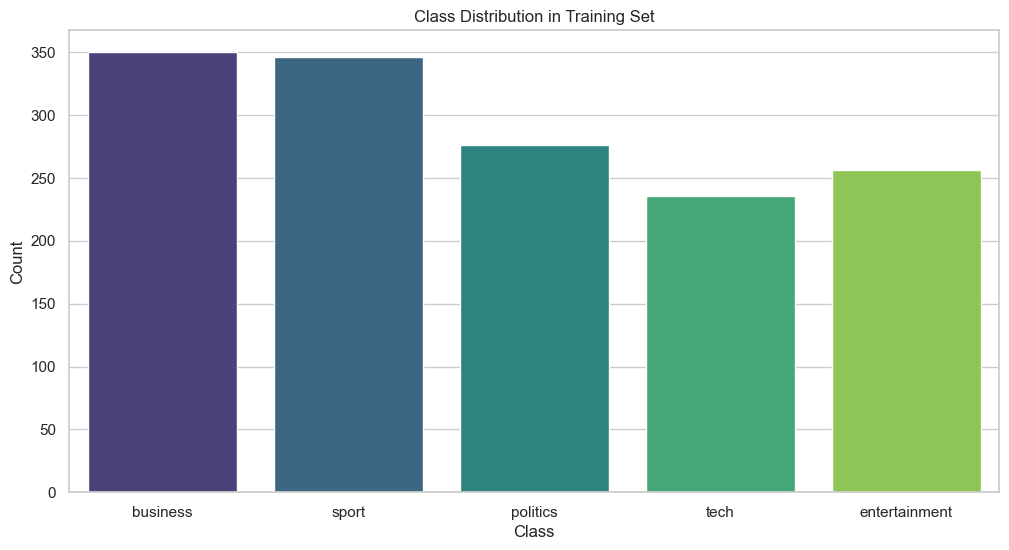

In [2]:
df = pd.read_csv('data.csv')

X = df['text'].to_numpy()
y = df['label'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
    )

print(f"Total samples: {len(df)}")
print(f"Training set: {len(X_train)}")
print(f"Testing set: {len(X_test)}")

plt.figure(figsize=(12, 6))
sns.countplot(
    x=y_train,
    hue=y_train,
    palette='viridis',
    legend=False
)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# II. VECTORIZING


In [6]:
vectorizer = TfidfVectorizer(
    tokenizer=preprocess_text,
    preprocessor=None,
    token_pattern=None,

    lowercase=False,

    ngram_range=(1, 2),

    min_df=2,
    max_df=0.85,
    max_features=30000,

    binary=False,

    smooth_idf=True,
    norm="l2",
    
    sublinear_tf=True,
)


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [7]:
len(vectorizer.vocabulary_)

30000

In [9]:
model = MultiClassSVM(
    C=0.01,
    kernel="linear",
)

model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.96      0.97      0.97       150
entertainment       0.98      0.96      0.97       110
     politics       0.95      0.97      0.96       119
        sport       0.99      0.99      0.99       148
         tech       0.97      0.94      0.95       101

     accuracy                           0.97       628
    macro avg       0.97      0.97      0.97       628
 weighted avg       0.97      0.97      0.97       628



# III. SELECTING CHI-SQUARE TOP K

In [6]:
for i in [100, 1000, 10000]:


  selector = ChiSquareSelector(
      k=i
  )

  X_train_chi = selector.fit_transform(
      X_train_tfidf,
      y_train
  )

  X_test_chi = selector.transform(
      X_test_tfidf
  )

  model = MultiClassSVM(
      C=0.01,
      kernel="linear",
  )

  model.fit(X_train_chi, y_train)
  y_pred = model.predict(X_test_chi)
  print(f"With Chi-square top k is {i}")
  print(classification_report(y_test, y_pred))

del selector
del X_train_chi
del X_test_chi
del model
del y_pred

With Chi-square top k is 50
               precision    recall  f1-score   support

     business       0.85      0.89      0.87       150
entertainment       0.90      0.80      0.85       110
     politics       0.88      0.90      0.89       119
        sport       0.86      0.93      0.89       148
         tech       0.91      0.81      0.86       101

     accuracy                           0.87       628
    macro avg       0.88      0.87      0.87       628
 weighted avg       0.88      0.87      0.87       628

With Chi-square top k is 100
               precision    recall  f1-score   support

     business       0.90      0.90      0.90       150
entertainment       0.94      0.83      0.88       110
     politics       0.88      0.92      0.90       119
        sport       0.90      0.97      0.93       148
         tech       0.92      0.89      0.90       101

     accuracy                           0.90       628
    macro avg       0.91      0.90      0.90       628
 we

# IV. INIT SELECTOR AND FIT TRANSFORM

In [34]:
selector = ChiSquareSelector(
    k=10000
)

X_train_chi = selector.fit_transform(
    X_train_tfidf,
    y_train
)

X_test_chi = selector.transform(
    X_test_tfidf
)

In [35]:
feature_names = vectorizer.get_feature_names_out()

selected_set = set(
    selector.selected_features_
)

mean_tfidf = np.asarray(
    X_train_tfidf.mean(axis=0)
).ravel()

df = pd.DataFrame({
    "term": feature_names,
    "tfidf": mean_tfidf,
    "chi": selector.scores_,
    "status": [
        "selected" if i in selected_set
        else "removed"
        for i in range(len(feature_names))
    ]
})

df = df.sort_values(
    "chi",
    ascending=False
)

df.to_csv(
    "chi2_result.csv",
    index=False,
    encoding="utf-8-sig"
)

# V. GRID SEARCH

In [11]:

param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.01, 0.1, 1, 10],
    },

    {
        "kernel": ["rbf"],
        "C": [0.01, 0.1, 1, 10],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    },

    {
        "kernel": ["poly"],
        "C": [0.01, 0.1, 1, 10],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        "degree": [2, 3],
    },

    {
        "kernel": ["sigmoid"],
        "C": [0.01, 0.1, 1, 10],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    }
]

print("Starting GridSearchCV...")

grid_search = GridSearchCV(
    estimator=MultiClassSVM(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=3,
    n_jobs=1,
)

grid_search.fit(X_train_chi, y_train)
print("\nBest Score:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Starting GridSearchCV...
Fitting 3 folds for each of 84 candidates, totalling 252 fits
[CV 1/3] END .............C=0.01, kernel=linear;, score=0.973 total time=   3.1s
[CV 2/3] END .............C=0.01, kernel=linear;, score=0.970 total time=   2.8s
[CV 3/3] END .............C=0.01, kernel=linear;, score=0.941 total time=   3.0s
[CV 1/3] END ..............C=0.1, kernel=linear;, score=0.973 total time=   2.5s
[CV 2/3] END ..............C=0.1, kernel=linear;, score=0.968 total time=   3.2s
[CV 3/3] END ..............C=0.1, kernel=linear;, score=0.939 total time=   3.0s
[CV 1/3] END ................C=1, kernel=linear;, score=0.979 total time=   2.8s
[CV 2/3] END ................C=1, kernel=linear;, score=0.981 total time=   2.7s
[CV 3/3] END ................C=1, kernel=linear;, score=0.972 total time=   2.5s
[CV 1/3] END ...............C=10, kernel=linear;, score=0.980 total time=   2.6s
[CV 2/3] END ...............C=10, kernel=linear;, score=0.982 total time=   2.5s
[CV 3/3] END .........

# VI. TRAIN WITH BEST PARAMETERS


In [12]:
bp = grid_search.best_params_

best_svm = MultiClassSVM(**bp)

print("Training final model...")
print("Best parameters:", bp)

best_svm.fit(X_train_chi, y_train)

print("Training complete.")

Training final model...
Best parameters: {'C': 10, 'kernel': 'linear'}
Training complete.


# VII. EVALUATION


CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     business       0.96      0.97      0.97       150
entertainment       0.98      0.98      0.98       110
     politics       0.95      0.97      0.96       119
        sport       1.00      0.99      1.00       148
         tech       0.98      0.95      0.96       101

     accuracy                           0.97       628
    macro avg       0.97      0.97      0.97       628
 weighted avg       0.97      0.97      0.97       628



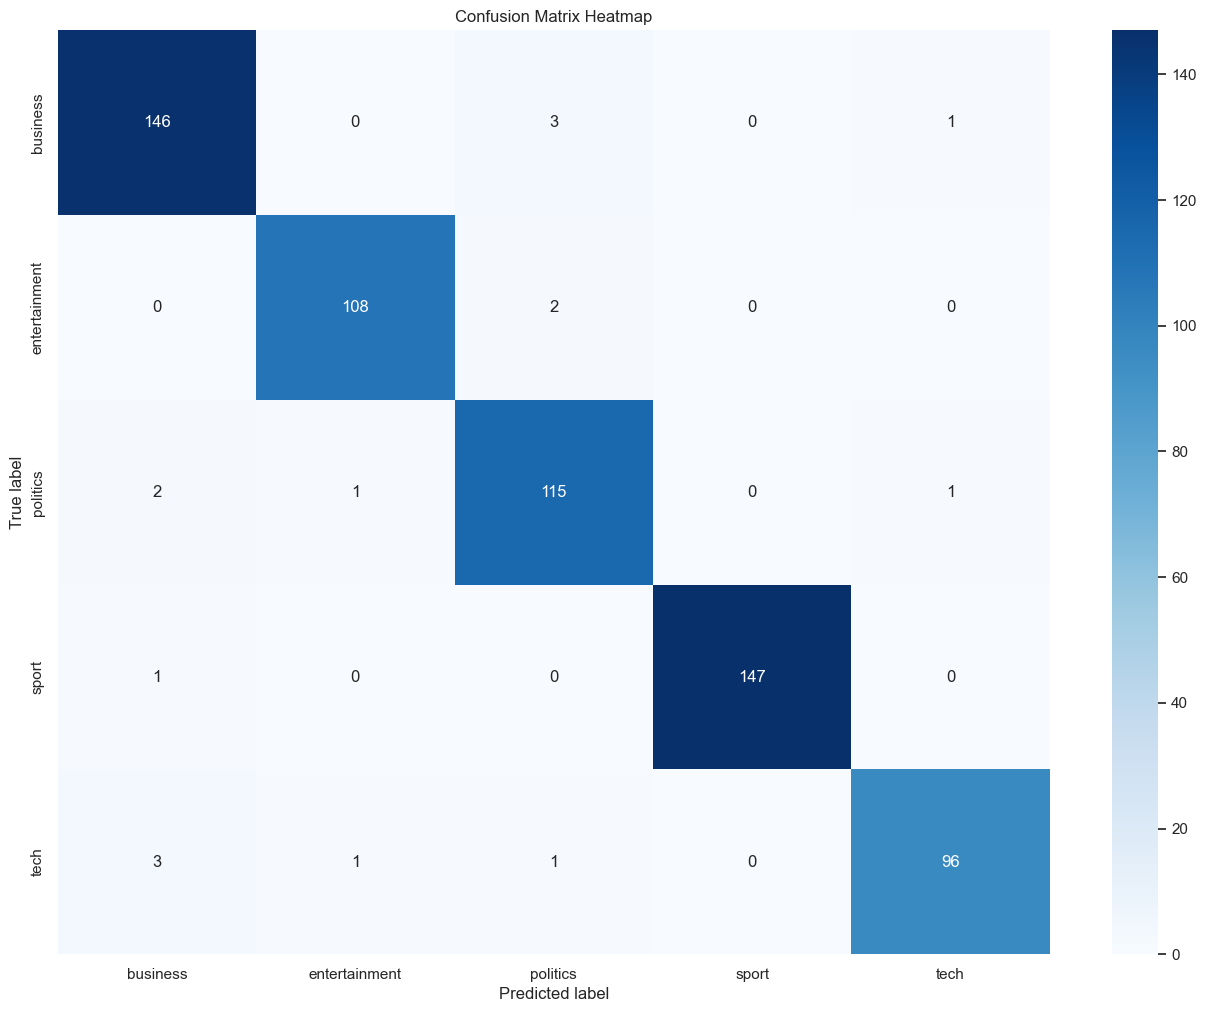

In [13]:
y_pred = best_svm.predict(X_test_chi)

# 1. Classification Report
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, zero_division=0))

from sklearn.metrics import ConfusionMatrixDisplay

# 2. Confusion Matrix
labels = sorted(set(y_test) | set(y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 12))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

ax.grid(False)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# VIII. TOP 20 TERM CHI2 SCORE

In [14]:
feature_names = vectorizer.get_feature_names_out()

top_idx = np.argsort(selector.scores_)[::-1]

for rank, idx in enumerate(top_idx[:20], start=1):
    print(
        f"{rank:2d}. "
        f"{feature_names[idx]:20s} "
        f"{selector.scores_[idx]:.4f}"
    )

 1. government           632.7416
 2. user                 616.2867
 3. minister             610.2623
 4. technology           608.6529
 5. election             599.1903
 6. party                594.1668
 7. film                 562.2062
 8. computer             544.2224
 9. tory                 535.6090
10. secretary            519.2325
11. star                 514.2685
12. firm                 482.2335
13. company              479.4688
14. game                 477.4292
15. market               473.8421
16. NUM MONEY            470.4487
17. player               468.0139
18. general election     461.2702
19. coach                457.9899
20. online               445.7525


# IX. TOP SAMPLES

In [15]:
import numpy as np
from sklearn.utils import check_random_state

rng = check_random_state(SEED)

y_pred = best_svm.predict(X_test_chi)
scores = best_svm.decision_function(X_test_chi)

feature_names = vectorizer.get_feature_names_out()

selected_idx = selector.selected_features_
selected_feature_names = np.array(feature_names)[selected_idx]
selected_chi2 = selector.scores_[selected_idx]

chi2_map = dict(
    zip(
        selected_feature_names,
        selected_chi2
    )
)

correct_idx = np.flatnonzero(y_pred == y_test)
wrong_idx = np.flatnonzero(y_pred != y_test)


def show_sample(idx):

    pred = y_pred[idx]
    true = y_test[idx]

    print("=" * 120)
    print(f"Sample #{idx}")
    print(f"True : {true}")
    print(f"Pred : {pred}")

    sample_scores = scores[idx]

    ranked = sorted(
        zip(
            best_svm.classes_,
            sample_scores
        ),
        key=lambda x: x[1],
        reverse=True
    )

    margin = (
        ranked[0][1] - ranked[1][1]
        if len(ranked) > 1
        else np.nan
    )

    print(f"Margin: {margin:.6f}")

    print("\nCLASS SCORES")
    print("-" * 120)

    for cls, score in ranked:
        marker = ""

        if cls == pred:
            marker += " [PRED]"

        if cls == true:
            marker += " [TRUE]"

        print(
            f"{str(cls):<20}"
            f"{score:>12.6f}"
            f"{marker}"
        )

    print("\nTEXT")
    print("-" * 120)
    print(X_test[idx])

    row = X_test_chi[idx]

    top_features = sorted(
        (
            (
                selected_feature_names[c],
                float(row[0, c]),
                chi2_map[
                    selected_feature_names[c]
                ]
            )
            for c in row.nonzero()[1]
        ),
        key=lambda x: x[1],
        reverse=True
    )[:30]

    print("\nTOP FEATURES")
    print("-" * 120)

    print(
        f"{'TERM':<35}"
        f"{'TFIDF':>12}"
        f"{'CHI2':>15}"
    )

    for term, tfidf, chi2_score in top_features:

        print(
            f"{term:<35}"
            f"{tfidf:>12.6f}"
            f"{chi2_score:>15.2f}"
        )

    print()



for title, indices in [
    ("CORRECT", correct_idx),
    ("WRONG", wrong_idx),
]:

    print("\n" + "#" * 120)
    print(title)
    print("#" * 120)

    if len(indices) == 0:
        continue

    for idx in rng.choice(
        indices,
        size=min(5, len(indices)),
        replace=False,
    ):
        show_sample(idx)


########################################################################################################################
CORRECT
########################################################################################################################
Sample #83
True : entertainment
Pred : entertainment
Margin: 0.803754

CLASS SCORES
------------------------------------------------------------------------------------------------------------------------
entertainment           0.218654 [PRED] [TRUE]
politics               -0.585100
tech                   -0.882052
sport                  -0.948356
business               -1.242312

TEXT
------------------------------------------------------------------------------------------------------------------------
CSI shows give 'unrealistic view'.  People have unrealistic expectations of forensic science thanks to the success of the CSI TV shows, real experts say.  Evidence submitted to forensic labs has shot up as a result of the programmes, at a

In [28]:
grid_df = pd.DataFrame(grid_search.cv_results_)

In [30]:
display(grid_df.sort_values(by="mean_test_score", ascending=False).head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,param_gamma,param_degree,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
3,2.587541,0.037500,0.030665,0.000474,10.0,linear,NaN,NaN,"{'C': 10, 'kernel': 'linear'}",0.979749,0.981921,0.978788,0.980153,0.001310,1
19,3.243267,0.170577,0.208869,0.016399,10.0,rbf,scale,NaN,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.979287,0.986117,0.974280,0.979895,0.004852,2
74,2.691270,0.006865,0.066063,0.000474,1.0,sigmoid,scale,NaN,"{'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.980989,0.981933,0.974356,0.979093,0.003371,3
79,2.957862,0.153423,0.070139,0.003637,10.0,sigmoid,scale,NaN,"{'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}",0.975702,0.981921,0.978788,0.978804,0.002539,4
23,2.616835,0.043558,0.138473,0.007234,10.0,rbf,0.1,NaN,"{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}",0.980989,0.981933,0.972032,0.978318,0.004461,5
83,2.685247,0.043253,0.092233,0.004022,10.0,sigmoid,0.1,NaN,"{'C': 10, 'gamma': 0.1, 'kernel': 'sigmoid'}",0.978997,0.983100,0.972076,0.978058,0.004549,6
14,2.879148,0.085664,0.228787,0.026646,1.0,rbf,scale,NaN,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.980962,0.977631,0.974280,0.977624,0.002728,7
2,2.702342,0.135562,0.035804,0.000201,1.0,linear,NaN,NaN,"{'C': 1, 'kernel': 'linear'}",0.978997,0.981272,0.972076,0.977448,0.003910,8
54,2.866324,0.102801,0.135629,0.017784,10.0,poly,scale,2.0,"{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}",0.981538,0.976611,0.961272,0.973140,0.008630,9
44,2.554189,0.055877,0.135419,0.005569,1.0,poly,scale,2.0,"{'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}",0.981403,0.972126,0.965614,0.973048,0.006479,10


# X. SAVING


In [16]:
# Final Export

joblib.dump(vectorizer, 'vectorizer.joblib')
joblib.dump(selector, 'selector.joblib')
joblib.dump(best_svm, 'svm_model.joblib')
joblib.dump(grid_search, 'grid_search.joblib')
print("Saved all")


Saved all


# XI. INFERENCE

In [17]:
import joblib
vectorizer = joblib.load('vectorizer.joblib')
selector = joblib.load('selector.joblib')
best_svm = joblib.load('svm_model.joblib')
grid_search = joblib.load('grid_search.joblib')

In [18]:
#
sample = """
The SpaceX Starship and Super Heavy Booster creates sound waves as it lifts off on its 12th test flight from the SpaceX launch complex in Starbase, Texas, U.S., May 22, 2026. REUTERS/Steve Nesius/File Photo Purchase Licensing Rights, opens new tab
SpaceX merged with Musk's AI startup xAI earlier this year in a deal that valued the rocket company ​at $1 trillion and the developer of the Grok AI chatbot at $250 billion.
The company has no direct peers, making valuing the company subject to interpretation.
Morningstar placed a $780 billion price tag on SpaceX, 48% below its current private-market valuation, according to a June 1 research note. Most of ‌that comes from ⁠its Starlink satellite communications business, which drove most of its revenue, profits and growth last year.
"""

In [19]:
sample_preprocessed = preprocess_text(sample)
print(sample_preprocessed, sep = ",")
print(len(sample_preprocessed))

['PERSON', 'starship', 'super', 'heavy', 'booster', 'create', 'sound', 'wave', 'lift', 'NUM', 'test', 'flight', 'PERSON', 'launch', 'complex', 'starbase', 'texas', 'u.s.', 'may', 'NUM', 'NUM', 'reuters', 'PERSON', 'purchase', 'licensing', 'rights', 'open', 'new', 'tab', 'PERSON', 'merge', 'PERSON', 'ai', 'startup', 'xai', 'early', 'year', 'deal', 'value', 'rocket', 'company', '\u200bat', 'MONEY', 'NUM', 'NUM', 'developer', 'grok', 'ai', 'chatbot', 'MONEY', 'NUM', 'NUM', 'company', 'direct', 'peer', 'make', 'value', 'company', 'subject', 'interpretation', 'PERSON', 'place', 'MONEY', 'NUM', 'NUM', 'price', 'tag', 'PERSON', 'NUM', 'current', 'private', 'market', 'valuation', 'accord', 'june', 'NUM', 'research', 'note', '\u200cthat', 'come', '\u2060it', 'starlink', 'satellite', 'communication', 'business', 'drive', 'revenue', 'profit', 'growth', 'last', 'year', 'PERSON', 'however', 'tie', 'growth', 'prospect', 'ai', 'plan', 'rely', 'yet', 'build', 'technology', 'significant', 'portion', 'f

In [20]:
analyzer = vectorizer.build_analyzer()
ngrams = analyzer(sample)
print(ngrams)

['PERSON', 'starship', 'super', 'heavy', 'booster', 'create', 'sound', 'wave', 'lift', 'NUM', 'test', 'flight', 'PERSON', 'launch', 'complex', 'starbase', 'texas', 'u.s.', 'may', 'NUM', 'NUM', 'reuters', 'PERSON', 'purchase', 'licensing', 'rights', 'open', 'new', 'tab', 'PERSON', 'merge', 'PERSON', 'ai', 'startup', 'xai', 'early', 'year', 'deal', 'value', 'rocket', 'company', '\u200bat', 'MONEY', 'NUM', 'NUM', 'developer', 'grok', 'ai', 'chatbot', 'MONEY', 'NUM', 'NUM', 'company', 'direct', 'peer', 'make', 'value', 'company', 'subject', 'interpretation', 'PERSON', 'place', 'MONEY', 'NUM', 'NUM', 'price', 'tag', 'PERSON', 'NUM', 'current', 'private', 'market', 'valuation', 'accord', 'june', 'NUM', 'research', 'note', '\u200cthat', 'come', '\u2060it', 'starlink', 'satellite', 'communication', 'business', 'drive', 'revenue', 'profit', 'growth', 'last', 'year', 'PERSON', 'however', 'tie', 'growth', 'prospect', 'ai', 'plan', 'rely', 'yet', 'build', 'technology', 'significant', 'portion', 'f

In [21]:
sample_tfidf = vectorizer.transform([sample])
sample_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 223 stored elements and shape (1, 30000)>

In [22]:
feature_names = vectorizer.get_feature_names_out()

pairs = sorted(
    zip(sample_tfidf.indices, sample_tfidf.data),
    key=lambda x: x[1],
    reverse=True
)

for idx, value in pairs:
    print(
        f"{feature_names[idx]:20s} {value:.4f}"
    )

open new             0.2060
ai                   0.1598
ipo                  0.1403
net loss             0.1403
valuation            0.1321
per share            0.1290
revenue              0.1257
wave                 0.1240
satellite            0.1180
multiple             0.1087
investor             0.1049
company PERSON       0.1022
loss                 0.0978
profit               0.0963
space                0.0951
reuters              0.0946
basis                0.0925
deal value           0.0863
interpretation PERSON 0.0863
market valuation     0.0863
month end            0.0863
place MONEY          0.0863
profit growth        0.0863
company              0.0863
MONEY NUM            0.0856
MONEY                0.0855
open                 0.0838
per                  0.0830
NUM developer        0.0829
NUM research         0.0829
anticipated          0.0829
end march            0.0829
intensify            0.0829
lift NUM             0.0829
likewise             0.0829
refer PERSON       

In [23]:
sample_chi = selector.transform(sample_tfidf)
sample_chi

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 114 stored elements and shape (1, 4000)>

In [32]:
selected_feature_names = (
    feature_names[
        selector.selected_features_
    ]
)

selected_chi_scores = (
    selector.scores_[
        selector.selected_features_
    ]
)

pairs = [
    (
        selected_feature_names[idx],
        selected_chi_scores[idx],
        value
    )
    for idx, value in zip(
        sample_chi.indices,
        sample_chi.data
    )
]

pairs.sort(
    key=lambda x: x[2],
    reverse=True
)

for term, chi2, tfidf in pairs:
    print(
        f"{term:30s}\t"
        f"TFIDF = {tfidf:.4f}\t"
        f"CHI2 = {chi2:.4f}\t"
    )

per share                     	TFIDF = 0.1290	CHI2 = 24.8745	
revenue                       	TFIDF = 0.1257	CHI2 = 95.7155	
satellite                     	TFIDF = 0.1180	CHI2 = 55.8759	
investor                      	TFIDF = 0.1049	CHI2 = 230.4186	
company PERSON                	TFIDF = 0.1022	CHI2 = 108.6798	
loss                          	TFIDF = 0.0978	CHI2 = 72.2228	
profit                        	TFIDF = 0.0963	CHI2 = 168.4832	
space                         	TFIDF = 0.0951	CHI2 = 32.5102	
reuters                       	TFIDF = 0.0946	CHI2 = 117.0460	
company                       	TFIDF = 0.0863	CHI2 = 479.4688	
MONEY NUM                     	TFIDF = 0.0856	CHI2 = 417.4331	
MONEY                         	TFIDF = 0.0855	CHI2 = 421.2357	
per                           	TFIDF = 0.0830	CHI2 = 57.9271	
cash                          	TFIDF = 0.0816	CHI2 = 34.8096	
price                         	TFIDF = 0.0804	CHI2 = 260.9038	
way around                    	TFIDF = 0.0802	CHI2 = 25.1539	


In [25]:
best_svm.predict_confidence(sample_chi)

array([[0.81626773, 0.03618804, 0.03188274, 0.03808916, 0.07757233]])

In [26]:
best_svm.predict(sample_chi)

array(['business'], dtype=object)